In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_exoplanets.csv")
print(df.shape)

(5757, 17)


In [3]:
def score_gaussian(value, ideal, tolerance):
    if pd.isna(value):
        return np.nan
    return np.exp(-((value - ideal) ** 2) / (2 * tolerance ** 2))

array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>]], dtype=object)

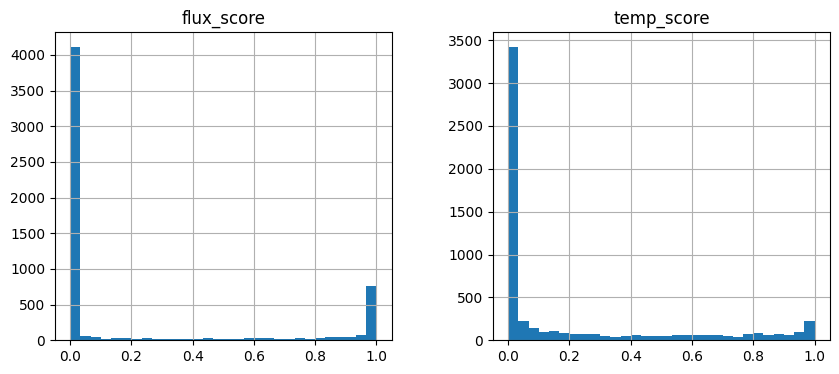

In [11]:
# Flux: widen tolerance significantly — real data spans orders of magnitude
df['flux_score'] = df['pl_insol'].apply(lambda x: score_gaussian(x, ideal=1.0, tolerance=5.0))

# Temperature: widen too — most planets are hundreds of K away from 255K
df['temp_score'] = df['pl_eqt'].apply(lambda x: score_gaussian(x, ideal=255, tolerance=150))

df[['flux_score','temp_score']].hist(figsize=(10,4), bins=30)

In [5]:
def score_asymmetric(value, ideal, tol_low, tol_high):
    if pd.isna(value):
        return np.nan
    tol = tol_low if value < ideal else tol_high
    return np.exp(-((value - ideal) ** 2) / (2 * tol ** 2))

# Radius: ideal = 1.0 Earth radii
df['radius_score'] = df['pl_rade'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.5, tol_high=0.6))

# Density proxy: ideal = 1.0 (Earth-like rocky density)
df['density_score'] = df['density_proxy'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.4, tol_high=0.8))

print(df[['pl_rade', 'radius_score', 'density_proxy', 'density_score']].describe())

           pl_rade  radius_score  density_proxy  density_score
count  5722.000000  5.722000e+03    5701.000000    5701.000000
mean      5.709506  2.263208e-01       2.530757       0.453827
std       5.414792  3.396014e-01      49.181701       0.340554
min       0.309800  0.000000e+00       0.005487       0.000000
25%       1.820000  3.852983e-66       0.248832       0.137985
50%       2.800000  1.110900e-02       0.474085       0.357858
75%      11.415000  3.930223e-01       0.850209       0.795891
max      87.205870  1.000000e+00    2517.401320       1.000000


In [6]:
def score_eccentricity(e, tolerance=0.3):
    if pd.isna(e):
        return np.nan
    return np.exp(-(e ** 2) / (2 * tolerance ** 2))

df['eccentricity_score'] = df['pl_orbeccen_filled'].apply(lambda x: score_eccentricity(x, tolerance=0.3))
print(df[['pl_orbeccen_filled', 'eccentricity_score']].describe())

       pl_orbeccen_filled  eccentricity_score
count         5757.000000         5757.000000
mean             0.071717            0.918833
std              0.147234            0.197438
min              0.000000            0.006645
25%              0.000000            0.968420
50%              0.000000            1.000000
75%              0.076000            1.000000
max              0.950000            1.000000


In [7]:
stability_map = {'M': 0.5, 'K': 0.9, 'G': 1.0, 'F': 0.75, 'A': 0.4, 'B': 0.1, 'O': 0.05}
df['stellar_score'] = df['spectral_class'].map(stability_map)

print(df['stellar_score'].value_counts(dropna=False))

stellar_score
NaN     3512
1.00     755
0.90     638
0.50     531
0.75     288
0.40      23
0.10      10
Name: count, dtype: int64


array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>],
       [<Axes: title={'center': 'radius_score'}>,
        <Axes: title={'center': 'density_score'}>],
       [<Axes: title={'center': 'eccentricity_score'}>,
        <Axes: title={'center': 'stellar_score'}>]], dtype=object)

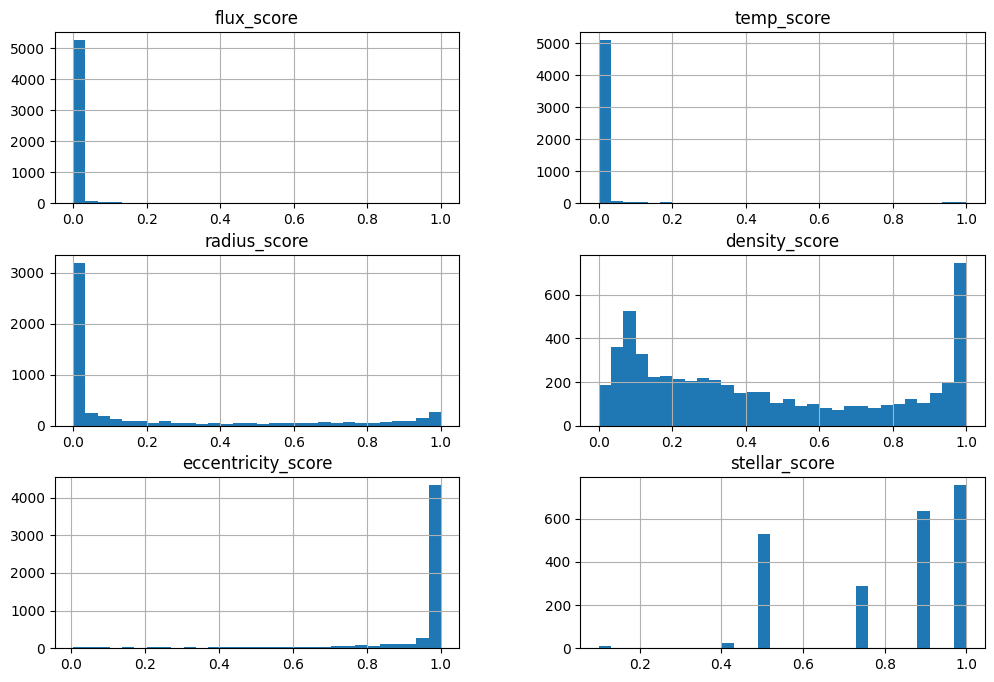

In [8]:
score_cols = ['flux_score', 'temp_score', 'radius_score', 'density_score', 'eccentricity_score', 'stellar_score']
df[score_cols].hist(figsize=(12, 8), bins=30)

In [10]:
print(df['pl_insol'].describe(percentiles=[.1,.25,.5,.75,.9]))
print(df['pl_eqt'].describe(percentiles=[.1,.25,.5,.75,.9]))

count      5715.000000
mean        532.630295
std        9979.045971
min           0.000000
10%           0.954840
25%          10.149000
50%          65.707000
75%         279.042500
90%         902.703400
max      636352.125800
Name: pl_insol, dtype: float64
count    5719.000000
mean      834.561960
std       494.651163
min         1.480000
10%       287.864000
25%       486.000000
50%       755.700000
75%      1093.000000
90%      1512.000000
max      7777.780000
Name: pl_eqt, dtype: float64


In [9]:
df.to_csv("../data/scored_exoplanets_partial.csv", index=False)

array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>]], dtype=object)

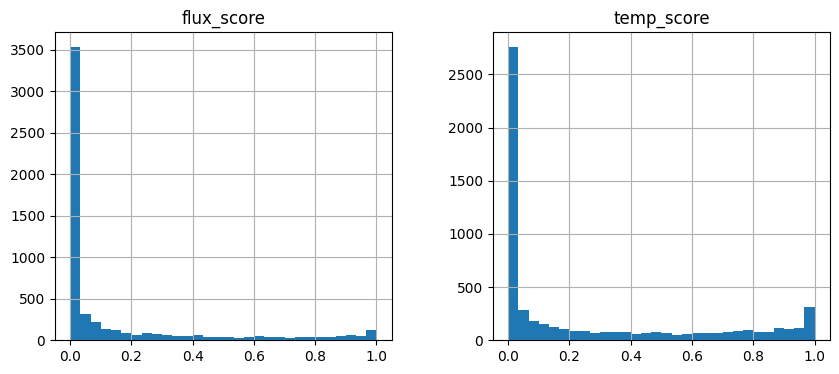

In [12]:
def score_gaussian_log(value, ideal_log, tolerance_log):
    if pd.isna(value) or value <= 0:
        return np.nan
    log_val = np.log10(value)
    return np.exp(-((log_val - ideal_log) ** 2) / (2 * tolerance_log ** 2))

def score_gaussian(value, ideal, tolerance):
    if pd.isna(value):
        return np.nan
    return np.exp(-((value - ideal) ** 2) / (2 * tolerance ** 2))

# Flux — log-space, ideal=log10(1.0)=0, tolerance_log=0.6 (covers ~1.5 orders of magnitude as "decent")
df['flux_score'] = df['pl_insol'].apply(lambda x: score_gaussian_log(x, ideal_log=0, tolerance_log=0.6))

# Temperature — linear, but widened to match real spread (75th percentile ~1093K, so tolerance needs to be in that ballpark)
df['temp_score'] = df['pl_eqt'].apply(lambda x: score_gaussian(x, ideal=255, tolerance=200))

df[['flux_score', 'temp_score']].hist(figsize=(10,4), bins=30)

array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>],
       [<Axes: title={'center': 'radius_score'}>,
        <Axes: title={'center': 'density_score'}>],
       [<Axes: title={'center': 'eccentricity_score'}>,
        <Axes: title={'center': 'stellar_score'}>]], dtype=object)

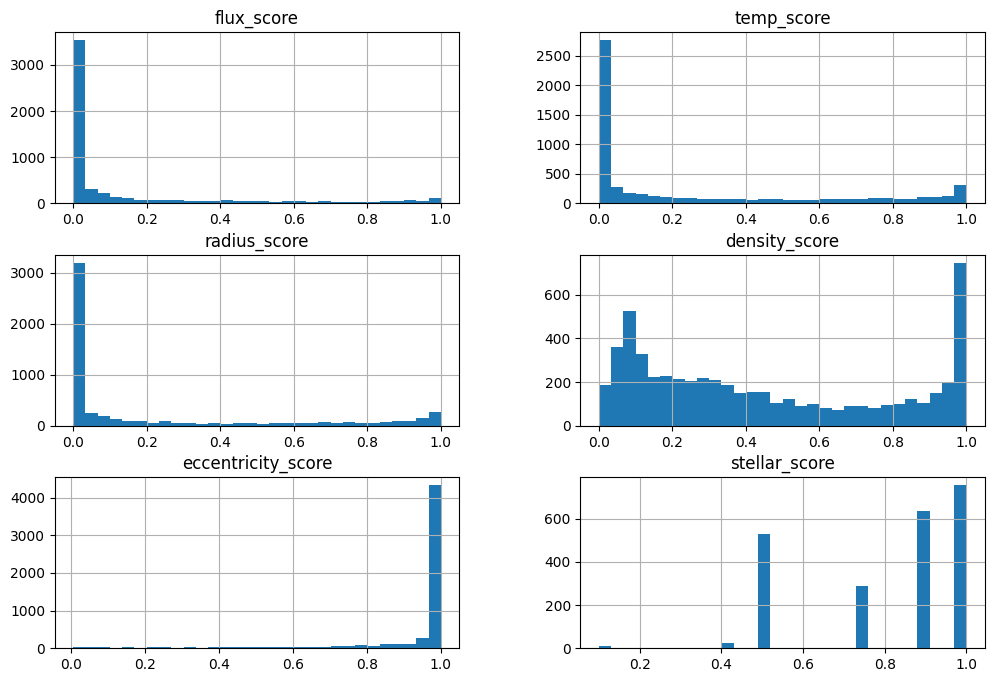

In [13]:
def score_asymmetric(value, ideal, tol_low, tol_high):
    if pd.isna(value):
        return np.nan
    tol = tol_low if value < ideal else tol_high
    return np.exp(-((value - ideal) ** 2) / (2 * tol ** 2))

df['radius_score'] = df['pl_rade'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.5, tol_high=0.6))
df['density_score'] = df['density_proxy'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.4, tol_high=0.8))

def score_eccentricity(e, tolerance=0.3):
    if pd.isna(e):
        return np.nan
    return np.exp(-(e ** 2) / (2 * tolerance ** 2))

df['eccentricity_score'] = df['pl_orbeccen_filled'].apply(lambda x: score_eccentricity(x, tolerance=0.3))

stability_map = {'M': 0.5, 'K': 0.9, 'G': 1.0, 'F': 0.75, 'A': 0.4, 'B': 0.1, 'O': 0.05}
df['stellar_score'] = df['spectral_class'].map(stability_map)

score_cols = ['flux_score', 'temp_score', 'radius_score', 'density_score', 'eccentricity_score', 'stellar_score']
df[score_cols].hist(figsize=(12, 8), bins=30)

In [14]:
print(df['pl_orbeccen'].isna().sum(), "filled with 0 out of", len(df))

533 filled with 0 out of 5757


In [15]:
df.to_csv("../data/scored_exoplanets_partial.csv", index=False)